# Model Training for Multi-Class Sentiment Analysis

This notebook loads data prepared in `01_data_preparation.ipynb`, trains candidate models, and evaluates them on the validation set. The test set remains untouched until the final model is selected.

## Import Required Libraries

In [3]:
import pickle

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
  ConfusionMatrixDisplay,
  accuracy_score,
  classification_report,
  f1_score,
  )
from sklearn.naive_bayes import ComplementNB
from sklearn.svm import LinearSVC

## Load Prepared Data

The pickle file contains TF-IDF matrices, target labels, and a vectorizer fitted exclusively on the training set.

In [4]:
with open("prepared_data.pkl", "rb") as f:
  (
    X_train, y_train,
    X_val, y_val,
    X_test, y_test,
    vectorizer,
  ) = pickle.load(f)

validation_texts = pd.read_csv("data/validation_df.csv")["Text"]
class_order = ["bad", "neutral", "good"]

In [5]:
assert X_train.shape[0] == len(y_train)
assert X_val.shape[0] == len(y_val) == len(validation_texts)
assert X_test.shape[0] == len(y_test)
assert X_train.shape[1] == X_val.shape[1] == X_test.shape[1]
assert X_train.shape[1] == len(vectorizer.get_feature_names_out())
assert set(y_train.unique()) == set(class_order)

summary = pd.DataFrame({
  "dataset": ["train", "validation", "test"],
  "num_examples": [X_train.shape[0], X_val.shape[0], X_test.shape[0]],
  "num_features": [X_train.shape[1], X_val.shape[1], X_test.shape[1]],
})
display(summary)

for name, labels in [("train", y_train), ("validation", y_val)]:
  print(f"\nClass distribution - {name}:")
  print(labels.value_counts().reindex(class_order, fill_value=0))

,dataset,num_examples,num_features
0,train,39999,10000
1,validation,5000,10000
2,test,5000,10000



Class distribution - train:
Score
bad        13333
neutral    13333
good       13333
Name: count, dtype: int64

Class distribution - validation:
Score
bad         484
neutral     347
good       4169
Name: count, dtype: int64


## Baseline: Multinomial Logistic Regression

The model is trained only on the training set. The validation set is used for the initial performance estimate and subsequent model comparison.

In [6]:
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train, y_train)

y_val_pred = model.predict(X_val)

In [7]:
print(f"Validation accuracy:    {accuracy_score(y_val, y_val_pred):.4f}")
print(f"Validation macro F1:    {f1_score(y_val, y_val_pred, average='macro'):.4f}")
print(f"Validation weighted F1: {f1_score(y_val, y_val_pred, average='weighted'):.4f}")
print("\nClassification report:\n")
print(classification_report(y_val, y_val_pred, labels=class_order, digits=4))

Validation accuracy:    0.8408
Validation macro F1:    0.6991
Validation weighted F1: 0.8622

Classification report:

              precision    recall  f1-score   support

         bad     0.6364    0.8244    0.7183       484
     neutral     0.3394    0.7493    0.4672       347
        good     0.9828    0.8503    0.9118      4169

    accuracy                         0.8408      5000
   macro avg     0.6529    0.8080    0.6991      5000
weighted avg     0.9046    0.8408    0.8622      5000



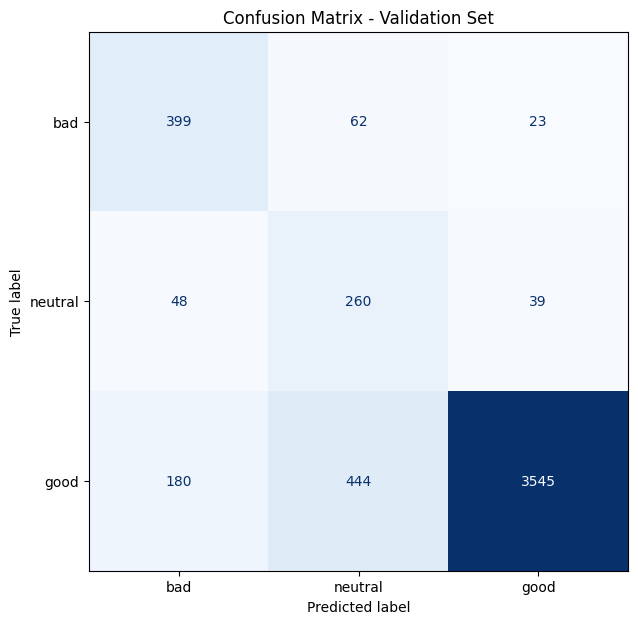

In [8]:
fig, ax = plt.subplots(figsize=(8, 7))
ConfusionMatrixDisplay.from_predictions(
  y_val,
  y_val_pred,
  labels=class_order,
  cmap="Blues",
  ax=ax,
  colorbar=False,
  )
ax.set_title("Confusion Matrix - Validation Set")
plt.show()

## LinearSVC and `C` Parameter Tuning

`LinearSVC` learns linear decision boundaries and performs well with sparse TF-IDF matrices. The `C` parameter controls regularization strength: a smaller `C` means stronger regularization. The best value is selected using macro F1 on the validation set.

In [9]:
c_values = [0.01, 0.03, 0.1, 0.3, 1.0]
svc_results = []
svc_models = {}

for c_value in c_values:
  candidate = LinearSVC(
    C=c_value,
    dual=True,
    max_iter=5000,
    random_state=42,
  )
  candidate.fit(X_train, y_train)
  candidate_pred = candidate.predict(X_val)

  svc_models[c_value] = candidate
  svc_results.append({
    "C": c_value,
    "accuracy": accuracy_score(y_val, candidate_pred),
    "macro_f1": f1_score(y_val, candidate_pred, average="macro"),
    "weighted_f1": f1_score(y_val, candidate_pred, average="weighted"),
  })

svc_results_df = pd.DataFrame(svc_results)
display(svc_results_df.round(4))

best_c = svc_results_df.loc[svc_results_df["macro_f1"].idxmax(), "C"]
best_svc = svc_models[best_c]
y_val_pred_svc = best_svc.predict(X_val)

print(f"Best C by validation macro F1: {best_c}")

,C,accuracy,macro_f1,weighted_f1
0,0.01,0.8198,0.6574,0.8432
1,0.03,0.8348,0.6798,0.8554
2,0.10,0.8496,0.7072,0.8682
3,0.30,0.8552,0.7159,0.8730
4,1.00,0.8506,0.7124,0.8702


Best C by validation macro F1: 0.3


In [10]:
print(f"LinearSVC validation accuracy:    {accuracy_score(y_val, y_val_pred_svc):.4f}")
print(f"LinearSVC validation macro F1:    {f1_score(y_val, y_val_pred_svc, average='macro'):.4f}")
print(f"LinearSVC validation weighted F1: {f1_score(y_val, y_val_pred_svc, average='weighted'):.4f}")
print("\nClassification report:\n")
print(classification_report(y_val, y_val_pred_svc, labels=class_order, digits=4))

LinearSVC validation accuracy:    0.8552
LinearSVC validation macro F1:    0.7159
LinearSVC validation weighted F1: 0.8730

Classification report:

              precision    recall  f1-score   support

         bad     0.6498    0.8471    0.7354       484
     neutral     0.3677    0.7406    0.4914       347
        good     0.9834    0.8657    0.9208      4169

    accuracy                         0.8552      5000
   macro avg     0.6669    0.8178    0.7159      5000
weighted avg     0.9084    0.8552    0.8730      5000



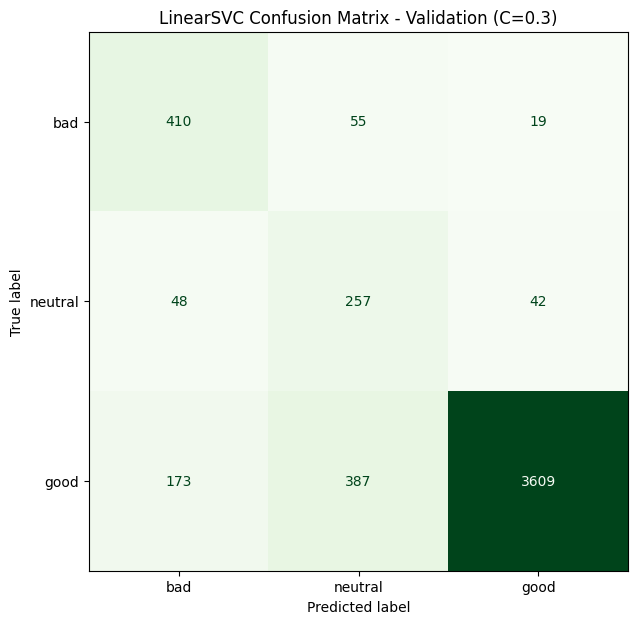

In [11]:
fig, ax = plt.subplots(figsize=(8, 7))
ConfusionMatrixDisplay.from_predictions(
  y_val,
  y_val_pred_svc,
  labels=class_order,
  cmap="Greens",
  ax=ax,
  colorbar=False,
  )
ax.set_title(f"LinearSVC Confusion Matrix - Validation (C={best_c:g})")
plt.show()

## ComplementNB

In addition to logistic regression and `LinearSVC`, we evaluate `ComplementNB`, which is designed for non-negative, sparse TF-IDF features.

In [12]:
nb_results = []
nb_models = {}

for alpha in [0.1, 0.5, 1.0, 2.0, 5.0]:
  candidate = ComplementNB(alpha=alpha)
  candidate.fit(X_train, y_train)
  candidate_pred = candidate.predict(X_val)

  nb_models[alpha] = candidate
  nb_results.append({
    "alpha": alpha,
    "accuracy": accuracy_score(y_val, candidate_pred),
    "macro_f1": f1_score(y_val, candidate_pred, average="macro"),
    "weighted_f1": f1_score(y_val, candidate_pred, average="weighted"),
  })

nb_results_df = pd.DataFrame(nb_results)
display(nb_results_df.round(4))

best_alpha = nb_results_df.loc[nb_results_df["macro_f1"].idxmax(), "alpha"]
best_nb = nb_models[best_alpha]
y_val_pred_nb = best_nb.predict(X_val)
print(f"Best alpha by validation macro F1: {best_alpha}")

,alpha,accuracy,macro_f1,weighted_f1
0,0.1,0.8524,0.6980,0.8677
1,0.5,0.8566,0.7025,0.8710
2,1.0,0.8592,0.7051,0.8729
3,2.0,0.8592,0.7025,0.8727
4,5.0,0.8584,0.7014,0.8721


Best alpha by validation macro F1: 1.0


## Model Comparison and Validation Error Analysis

In [13]:
validation_predictions = {
  "LogisticRegression": y_val_pred,
  "LinearSVC": y_val_pred_svc,
  "ComplementNB": y_val_pred_nb,
}

comparison_rows = []
for model_name, predictions in validation_predictions.items():
  comparison_rows.append({
    "model": model_name,
    "accuracy": accuracy_score(y_val, predictions),
    "macro_f1": f1_score(y_val, predictions, average="macro"),
    "weighted_f1": f1_score(y_val, predictions, average="weighted"),
  })

comparison_df = (
  pd.DataFrame(comparison_rows)
  .sort_values("macro_f1", ascending=False)
  .reset_index(drop=True)
  )
display(comparison_df.round(4))

best_model_name = comparison_df.loc[0, "model"]
best_validation_pred = validation_predictions[best_model_name]
print(f"Selected model by validation macro F1: {best_model_name}")

,model,accuracy,macro_f1,weighted_f1
0,LinearSVC,0.8552,0.7159,0.8730
1,ComplementNB,0.8592,0.7051,0.8729
2,LogisticRegression,0.8408,0.6991,0.8622


Selected model by validation macro F1: LinearSVC


In [14]:
validation_analysis = pd.DataFrame({
  "text": validation_texts.astype(str),
  "actual": np.asarray(y_val),
  "predicted": best_validation_pred,
})
validation_analysis["is_misclassified"] = (
  validation_analysis["actual"] != validation_analysis["predicted"]
  )

confusion_pairs = (
  validation_analysis.loc[validation_analysis["is_misclassified"]]
  .groupby(["actual", "predicted"])
  .size()
  .sort_values(ascending=False)
  .rename("count")
  .reset_index()
  )
display(confusion_pairs.head(10))

misclassified_examples = (
  validation_analysis.loc[validation_analysis["is_misclassified"]]
  .head(10)
  .copy()
  )
misclassified_examples["text"] = misclassified_examples["text"].str.slice(0, 300)
display(misclassified_examples)

,actual,predicted,count
0,good,neutral,387
1,good,bad,173
2,bad,neutral,55
3,neutral,bad,48
4,neutral,good,42
5,bad,good,19


,text,actual,predicted,is_misclassified
30,The customer service was beyond compare. I wo...,good,bad,True
34,This product is the same as I had purchased fr...,good,neutral,True
44,"<a href=""http://www.amazon.com/gp/product/B003...",good,neutral,True
58,Doesn't give you the jitters and doesn't tast ...,good,neutral,True
59,And they are good for them! With whole wheat f...,good,neutral,True
64,"Coffee tastes as good as from Starbucks, k-cup...",good,bad,True
69,This is a very tasty olive oil but way too pri...,good,neutral,True
83,Maybe it's a psychological thang but it seems ...,good,neutral,True
84,"Based on past experience, I couldn't accept th...",good,bad,True
88,I couldn't find this in any grocery store arou...,good,neutral,True


## Final Evaluation on the Test Set

After selecting the model exclusively by validation macro F1, the test set is used once for the final unbiased evaluation.

Final model: LinearSVC
Test accuracy: 0.8650
Test macro_f1: 0.7310
Test weighted_f1: 0.8808

Test classification report:

              precision    recall  f1-score   support

         bad     0.6736    0.8698    0.7592       484
     neutral     0.3857    0.7435    0.5079       347
        good     0.9838    0.8746    0.9260      4169

    accuracy                         0.8650      5000
   macro avg     0.6810    0.8293    0.7310      5000
weighted avg     0.9123    0.8650    0.8808      5000



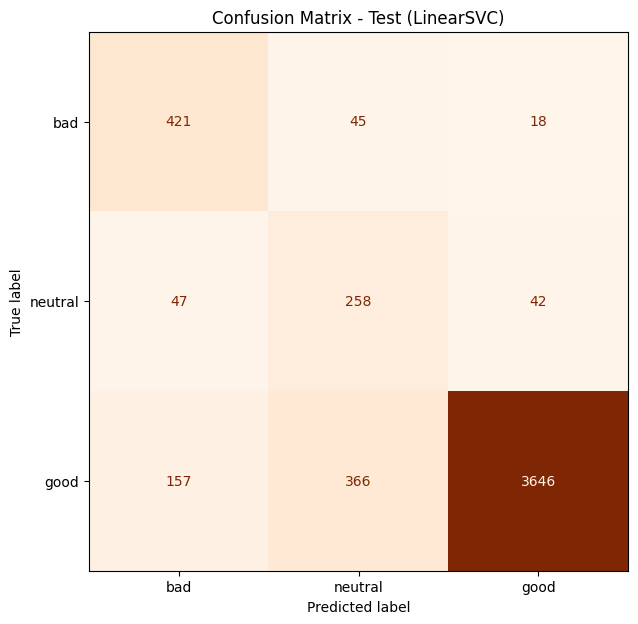

In [15]:
if best_model_name == "LogisticRegression":
  final_model = model
elif best_model_name == "LinearSVC":
  final_model = best_svc
else:
  final_model = best_nb

y_test_pred = final_model.predict(X_test)

test_metrics = {
  "accuracy": accuracy_score(y_test, y_test_pred),
  "macro_f1": f1_score(y_test, y_test_pred, average="macro"),
  "weighted_f1": f1_score(y_test, y_test_pred, average="weighted"),
}

print(f"Final model: {best_model_name}")
for metric_name, metric_value in test_metrics.items():
  print(f"Test {metric_name}: {metric_value:.4f}")
print("\nTest classification report:\n")
print(classification_report(y_test, y_test_pred, labels=class_order, digits=4))

fig, ax = plt.subplots(figsize=(8, 7))
ConfusionMatrixDisplay.from_predictions(
  y_test,
  y_test_pred,
  labels=class_order,
  cmap="Oranges",
  ax=ax,
  colorbar=False,
  )
ax.set_title(f"Confusion Matrix - Test ({best_model_name})")
plt.show()

In [16]:
model_artifact = {
  "model_name": best_model_name,
  "model": final_model,
  "vectorizer": vectorizer,
  "validation_results": comparison_df,
  "test_metrics": test_metrics,
  "classes": class_order,
  "feature_count": X_train.shape[1],
}

joblib.dump(model_artifact, "sentiment_model.joblib")
print("Model saved to sentiment_model.joblib")

Model saved to sentiment_model.joblib


## Models Trained on the Imbalanced Dataset

The same model families and validation-based hyperparameter selection are repeated using `prepared_data_imbalanced.pkl`. Validation and test labels are asserted to match the balanced experiment, so the final table isolates the effect of the training distribution.

In [17]:
with open("prepared_data_imbalanced.pkl", "rb") as f:
  (
    X_train_imb, y_train_imb,
    X_val_imb, y_val_imb,
    X_test_imb, y_test_imb,
    vectorizer_imb,
  ) = pickle.load(f)

assert y_val_imb.reset_index(drop=True).equals(y_val.reset_index(drop=True))
assert y_test_imb.reset_index(drop=True).equals(y_test.reset_index(drop=True))
assert X_train_imb.shape == (40000, 10000)

imbalanced_candidates = {}
imbalanced_validation_rows = []

logistic_imb = LogisticRegression(max_iter=1000, random_state=42)
logistic_imb.fit(X_train_imb, y_train_imb)
imbalanced_candidates["LogisticRegression"] = logistic_imb

for c_value in c_values:
  candidate = LinearSVC(C=c_value, dual=True, max_iter=5000, random_state=42)
  candidate.fit(X_train_imb, y_train_imb)
  candidate_pred = candidate.predict(X_val_imb)
  imbalanced_validation_rows.append({
    "model": f"LinearSVC (C={c_value})",
    "family": "LinearSVC",
    "parameter": c_value,
    "macro_f1": f1_score(y_val_imb, candidate_pred, average="macro"),
  })
  imbalanced_candidates[f"LinearSVC (C={c_value})"] = candidate

for alpha in [0.1, 0.5, 1.0, 2.0, 5.0]:
  candidate = ComplementNB(alpha=alpha)
  candidate.fit(X_train_imb, y_train_imb)
  candidate_pred = candidate.predict(X_val_imb)
  imbalanced_validation_rows.append({
    "model": f"ComplementNB (alpha={alpha})",
    "family": "ComplementNB",
    "parameter": alpha,
    "macro_f1": f1_score(y_val_imb, candidate_pred, average="macro"),
  })
  imbalanced_candidates[f"ComplementNB (alpha={alpha})"] = candidate

logistic_imb_pred = logistic_imb.predict(X_val_imb)
imbalanced_validation_rows.append({
  "model": "LogisticRegression",
  "family": "LogisticRegression",
  "parameter": np.nan,
  "macro_f1": f1_score(y_val_imb, logistic_imb_pred, average="macro"),
})

imbalanced_validation_df = (
  pd.DataFrame(imbalanced_validation_rows)
  .sort_values("macro_f1", ascending=False)
  .reset_index(drop=True)
)
best_imbalanced_name = imbalanced_validation_df.loc[0, "model"]
best_imbalanced_model = imbalanced_candidates[best_imbalanced_name]
y_test_pred_imb = best_imbalanced_model.predict(X_test_imb)

imbalanced_test_metrics = {
  "accuracy": accuracy_score(y_test_imb, y_test_pred_imb),
  "macro_f1": f1_score(y_test_imb, y_test_pred_imb, average="macro"),
  "weighted_f1": f1_score(y_test_imb, y_test_pred_imb, average="weighted"),
}

print("Imbalanced training distribution:")
print(y_train_imb.value_counts().reindex(class_order))
print(f"\nSelected model: {best_imbalanced_name}")
display(imbalanced_validation_df.round(4))
print("\nTest classification report:\n")
print(classification_report(y_test_imb, y_test_pred_imb, labels=class_order, digits=4))

balanced_vs_imbalanced = pd.DataFrame([
  {"training_set": "balanced", "model": best_model_name, **test_metrics},
  {"training_set": "imbalanced", "model": best_imbalanced_name, **imbalanced_test_metrics},
])
display(balanced_vs_imbalanced.round(4))

Imbalanced training distribution:
Score
bad         3869
neutral     2778
good       33353
Name: count, dtype: int64

Selected model: LinearSVC (C=1.0)


,model,family,parameter,macro_f1
0,LinearSVC (C=1.0),LinearSVC,1.00,0.7442
1,LinearSVC (C=0.3),LinearSVC,0.30,0.7233
2,LogisticRegression,LogisticRegression,NaN,0.7161
3,ComplementNB (alpha=2.0),ComplementNB,2.00,0.6845
4,LinearSVC (C=0.1),LinearSVC,0.10,0.6795
5,ComplementNB (alpha=0.1),ComplementNB,0.10,0.6767
6,ComplementNB (alpha=1.0),ComplementNB,1.00,0.6730
7,ComplementNB (alpha=0.5),ComplementNB,0.50,0.6684
8,ComplementNB (alpha=5.0),ComplementNB,5.00,0.6456
9,LinearSVC (C=0.03),LinearSVC,0.03,0.5756



Test classification report:

              precision    recall  f1-score   support

         bad     0.8230    0.7397    0.7791       484
     neutral     0.6610    0.4496    0.5352       347
        good     0.9448    0.9811    0.9626      4169

    accuracy                         0.9208      5000
   macro avg     0.8096    0.7234    0.7590      5000
weighted avg     0.9133    0.9208    0.9152      5000



,training_set,model,accuracy,macro_f1,weighted_f1
0,balanced,LinearSVC,0.8650,0.731,0.8808
1,imbalanced,LinearSVC (C=1.0),0.9208,0.759,0.9152
